### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, **weights**
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty **FOR COMPARISON PURPOSES**
2. Model 2: Fit on training (with weights) → Predict on test → Compute fairness metrics, **penalty FOR COMPARISON PURPOSES**

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

In [1]:
import sys
sys.path.insert(0, '../utils')

from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [2]:
dataset_path = '../../AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


In [3]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

# Choose subgroup

In [4]:
sensible_attribute = 'sex-race'

In [5]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [6]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}
performance_metrics_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}
performance_metrics_test = {}


for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute], performance_metrics_val[attribute] = \
    compute_model_predictions_catboost(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute], performance_metrics_test[attribute] = \
    compute_model_predictions_catboost(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


Learning rate set to 0.039148
0:	learn: 0.6561409	total: 154ms	remaining: 2m 34s
1:	learn: 0.6230785	total: 164ms	remaining: 1m 22s
2:	learn: 0.5949357	total: 174ms	remaining: 57.8s
3:	learn: 0.5651217	total: 184ms	remaining: 45.8s
4:	learn: 0.5408014	total: 194ms	remaining: 38.6s
5:	learn: 0.5168438	total: 204ms	remaining: 33.8s
6:	learn: 0.4988213	total: 215ms	remaining: 30.4s
7:	learn: 0.4823739	total: 228ms	remaining: 28.3s
8:	learn: 0.4671640	total: 240ms	remaining: 26.4s
9:	learn: 0.4558284	total: 251ms	remaining: 24.8s
10:	learn: 0.4466797	total: 261ms	remaining: 23.4s
11:	learn: 0.4363360	total: 271ms	remaining: 22.4s
12:	learn: 0.4275185	total: 282ms	remaining: 21.4s
13:	learn: 0.4185434	total: 294ms	remaining: 20.7s
14:	learn: 0.4101983	total: 306ms	remaining: 20.1s
15:	learn: 0.4026951	total: 317ms	remaining: 19.5s
16:	learn: 0.3966031	total: 331ms	remaining: 19.1s
17:	learn: 0.3913461	total: 344ms	remaining: 18.8s
18:	learn: 0.3868474	total: 355ms	remaining: 18.3s
19:	learn

# Plot Confusion Matrix

In [7]:
def plot_confusion_matrix(cm_data, forwhat=''):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create figure with subplots for each subgroup
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Confusion Matrices by Subgroup: {sensible_attribute} {forwhat}', fontsize=16, fontweight='bold')

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Subgroups and their decoded labels
    subgroups = ['00', '01', '10', '11']
    individual_attrs = sensible_attribute.split('-')

    # Iterate through subgroups
    for idx, group in enumerate(subgroups):
        ax = axes[idx]
        
        if group in cm_data:
            cm = cm_data[group]
            
            # Create heatmap with counts
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar_kws={'label': 'Count'}, vmin=0,
                        xticklabels=['Pred Neg', 'Pred Pos'],
                        yticklabels=['True Neg', 'True Pos'])
            
            # Decode group label
            attr1_val = mapping[individual_attrs[0]][int(group[0])]
            attr2_val = mapping[individual_attrs[1]][int(group[1])]
            
            # Calculate metrics for subtitle
            tn, fp, fn, tp = cm.ravel()
            total = tn + fp + fn + tp
            
            # Add text labels (TN, FP, FN, TP) on each cell
            labels = [['TN', 'FP'], ['FN', 'TP']]
            for i in range(2):
                for j in range(2):
                    text = ax.text(j + 0.5, i + 0.3, labels[i][j],
                                 ha='center', va='center',
                                 color='darkred', fontsize=7, fontweight='bold')
            
            # Title with decoded labels and sample count
            ax.set_title(f'Group {group}: {attr1_val} & {attr2_val}\n' + 
                        f'N = {total}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Predicted Label', fontsize=10)
            ax.set_ylabel('True Label', fontsize=10)
        else:
            # Handle missing subgroups
            ax.text(0.5, 0.5, f'Group {group}\nNo Data', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

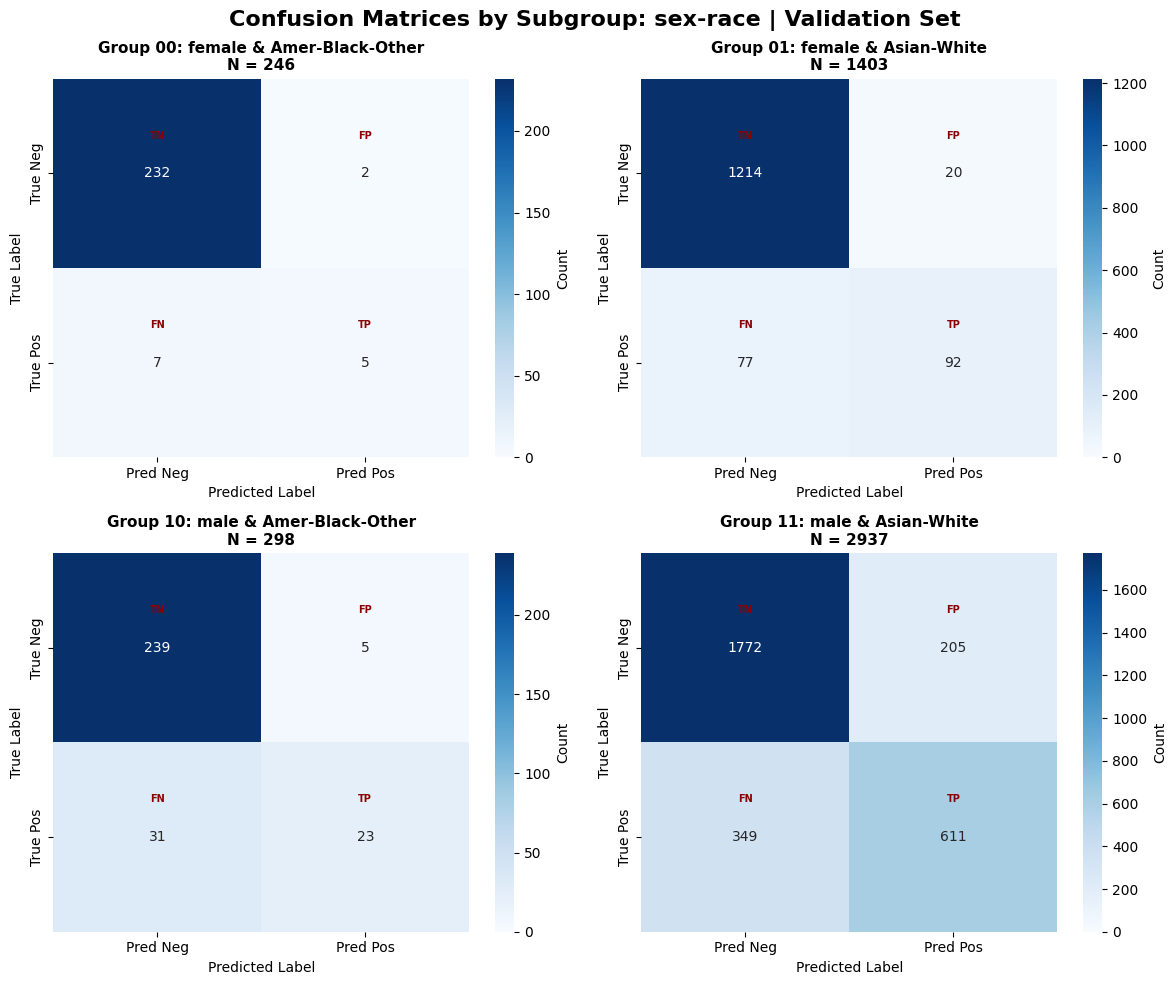

In [8]:
plot_confusion_matrix(cm_dict_val[sensible_attribute], '| Validation Set')

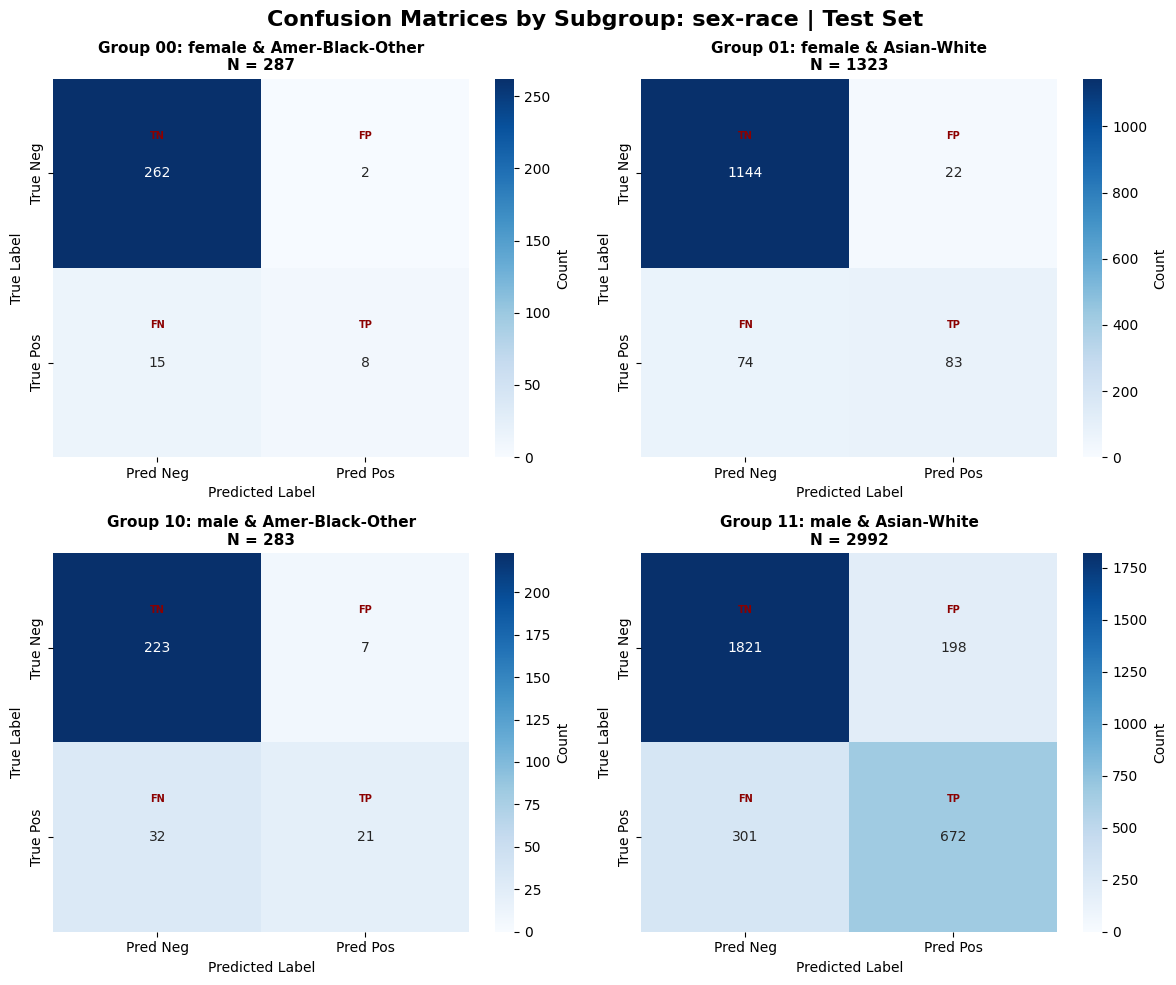

In [9]:
plot_confusion_matrix(cm_dict_test[sensible_attribute], '| Test Set')

# Compute Penalties: Validation and Test

Compute harmonic, geometric and arithmetic penalties, but only use harmonic for simplicity

In [10]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

# Weights Functions

Three ways of calculating the weights, all **implemented** with the same function above (Model 2)

MAINLY FOCUSING ON NOTSIZED WEIGHTS.



### $w_i = 1 + \lambda * Penalty(g_i) $

This type of weight calculation has proven to be the most reliable and consistent, so we are mainly focusing on it during experiments.

In [11]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [12]:
def compute_weights_notsized(lambda_=5.0, m='FPN'):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


In [13]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}


### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [14]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [15]:
def compute_weights_sized(lambda_=1.0, m='PPE'):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [16]:
weights_sized = compute_weights_sized(10.0)

Training samples: 22792, Unique weights per group: {'00': 1.3793778008155968, '01': 2.5505968713987874, '10': 1.1863230129329092, '11': 0.01}


---

In [17]:
def compute_fixed_weights(lambda_=5.0, m='FPN', fixed_weights=None):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }

    weights_notsized = fixed_weights # in the form of a dictionary {'00': weight1, '01': weight2, ...}

    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized

# Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [18]:
def compute_penalties_after_reweighting(weights, fairness_metric):
    # Train Model 2 ONLY on the combined attribute (sensible_attribute) with weights
    import catboost as cb
    
    # Convert string combinations to numeric codes for catboost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = cb.CatBoostClassifier(random_seed=1234, eval_metric='Logloss', verbose=False)
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)
    
    # Compute fairness metrics for ALL attributes (individual + combined)
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    fairness_metrics_dict_test_reweighed = {}
    
    for attribute in attributes:
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute FAIRNESS METRICS for each attribute on TEST set
        # Use the SAME predictions (from combined attribute) for all attributes
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed_combined, y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic

### Example

In [19]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
compute_penalties_after_reweighting(weights_notsized, 'FPN')

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
{np.int64(0): array([[1405,   25],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
{np.int64(1): array([[2964,  221],
       [ 374,  756]]), np.int64(0): array([[485,   9],
       [ 46,  30]])}
{'01': array([[1144,   22],
       [  74,   83]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[224,   6],
       [ 32,  21]])}


{'00': 6.196078431372537,
 '01': 17.35897435897437,
 '10': 31.07402652973899,
 '11': -5.917049859569046}

In [20]:
# Hard code weights not sized

compute_penalties_after_reweighting(weights_notsized, 'FPN')

{np.int64(0): array([[1405,   25],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
{np.int64(1): array([[2964,  221],
       [ 374,  756]]), np.int64(0): array([[485,   9],
       [ 46,  30]])}
{'01': array([[1144,   22],
       [  74,   83]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[224,   6],
       [ 32,  21]])}


{'00': 6.196078431372537,
 '01': 17.35897435897437,
 '10': 31.07402652973899,
 '11': -5.917049859569046}

# Performance Comparison

In [21]:
def performance_after_reweighting(weights): 
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

    perf_metrics = performance_metrics(y_test[sensible_attribute], y_pred_test_reweighed_combined)
    
    return perf_metrics


In [ ]:
performance_metrics_test[sensible_attribute]

(0.773938795656466, 0.6500829187396352, 0.8667349027635619, 0.7066246056782335)

In [23]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
performance_metrics_after = performance_after_reweighting(weights_notsized)

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
Precision: 0.7750247770069376, Recall: 0.648424543946932, Accuracy: 0.8667349027635619, F1: 0.7060948081264108


Observation: performance remains stable (in some cases even better). For higher lambdas (>20), the performance starts to drop. 

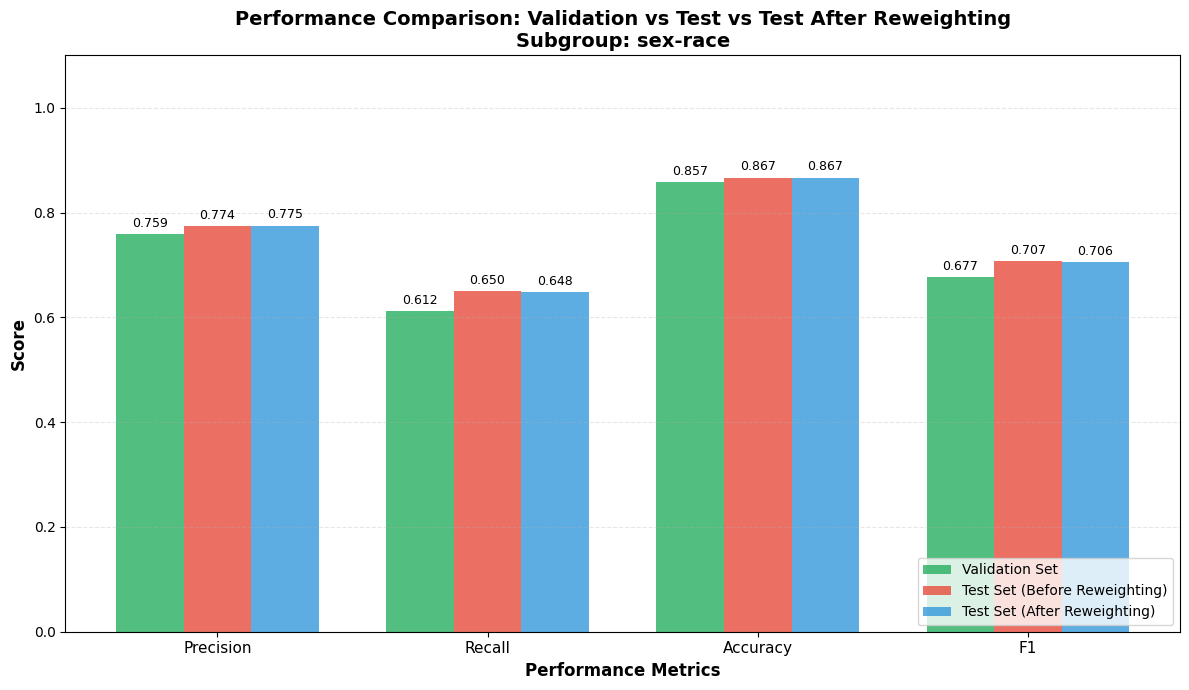


Performance Metrics Comparison:
Metric          Validation      Test (Before)   Test (After)    Δ (After-Before)
--------------------------------------------------------------------------------
Precision       0.7591          0.7739          0.7750          +0.0011
Recall          0.6117          0.6501          0.6484          -0.0017
Accuracy        0.8575          0.8667          0.8667          +0.0000
F1              0.6775          0.7066          0.7061          -0.0005


In [24]:
# Plot performance comparison
plot_performance_comparison(performance_metrics_val, performance_metrics_test, performance_metrics_after, sensible_attribute)

---

# Penalty After Reweighting Plots

### Utils

In [25]:
penalties_ontest_after_reweighting = {}
cm_dict_reweighted = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(5.0, metric)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
    # print("\n")

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
{np.int64(0): array([[1405,   25],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
{np.int64(1): array([[2964,  221],
       [ 374,  756]]), np.int64(0): array([[485,   9],
       [ 46,  30]])}
{'01': array([[1144,   22],
       [  74,   83]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[224,   6],
       [ 32,  21]])}
Training samples: 22792, Unique weights per group: {'00': 3.1151071151071146, '01': 2.725664260105102, '10': 1.967574573121791, '11': 0.01}
{np.int64(0): array([[1407,   23],
       [  90,   90]]), np.int64(1): array([[2009,  240],
       [ 350,  676]])}
{np.int64(1): array([[2931,  254],
       [ 391,  739]]), np.int64(0): array([[485,   9],
       [ 49,  27]])}
{'01': array([[1145,   21],
       [  75,   82]]), '00': array([[262,   2

## Penalty before and after reweighting

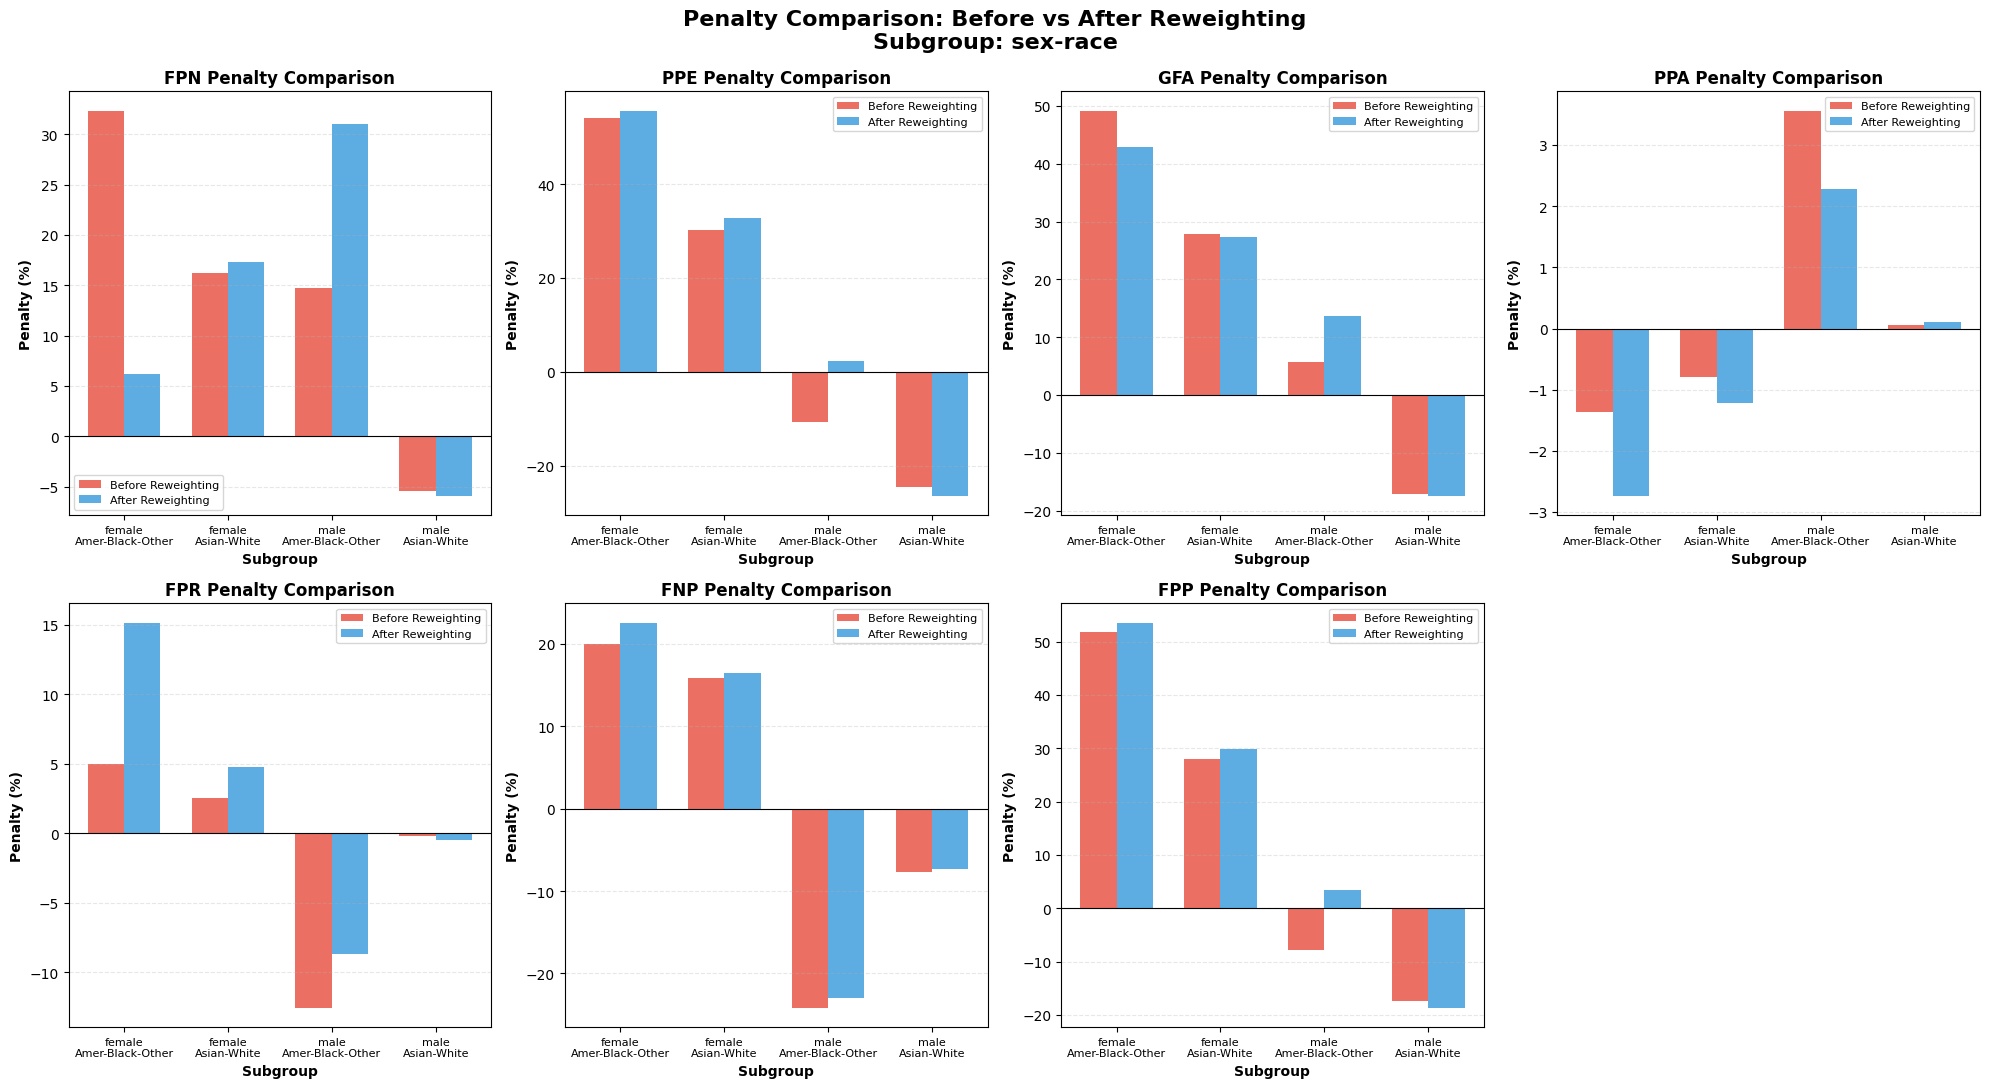

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

# Use the generalized function
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping)

Training samples: 22792, Unique weights per group: {'00': 0.8777056277056277, '01': 1.1061263749815025, '10': 1.1799547283702214, '11': 0.9766622488111263}
{np.int64(0): array([[1407,   23],
       [  89,   91]]), np.int64(1): array([[2045,  204],
       [ 334,  692]])}
{np.int64(1): array([[2966,  219],
       [ 376,  754]]), np.int64(0): array([[486,   8],
       [ 47,  29]])}
{'01': array([[1145,   21],
       [  75,   82]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1821,  198],
       [ 301,  672]]), '10': array([[224,   6],
       [ 33,  20]])}
Training samples: 22792, Unique weights per group: {'00': 1.2115107115107115, '01': 1.1725664260105102, '10': 1.096757457312179, '11': 0.8646098263836941}
{np.int64(0): array([[1408,   22],
       [  90,   90]]), np.int64(1): array([[2045,  204],
       [ 335,  691]])}
{np.int64(1): array([[2967,  218],
       [ 377,  753]]), np.int64(0): array([[486,   8],
       [ 48,  28]])}
{'01': array([[1146,   20],
       [  75,   

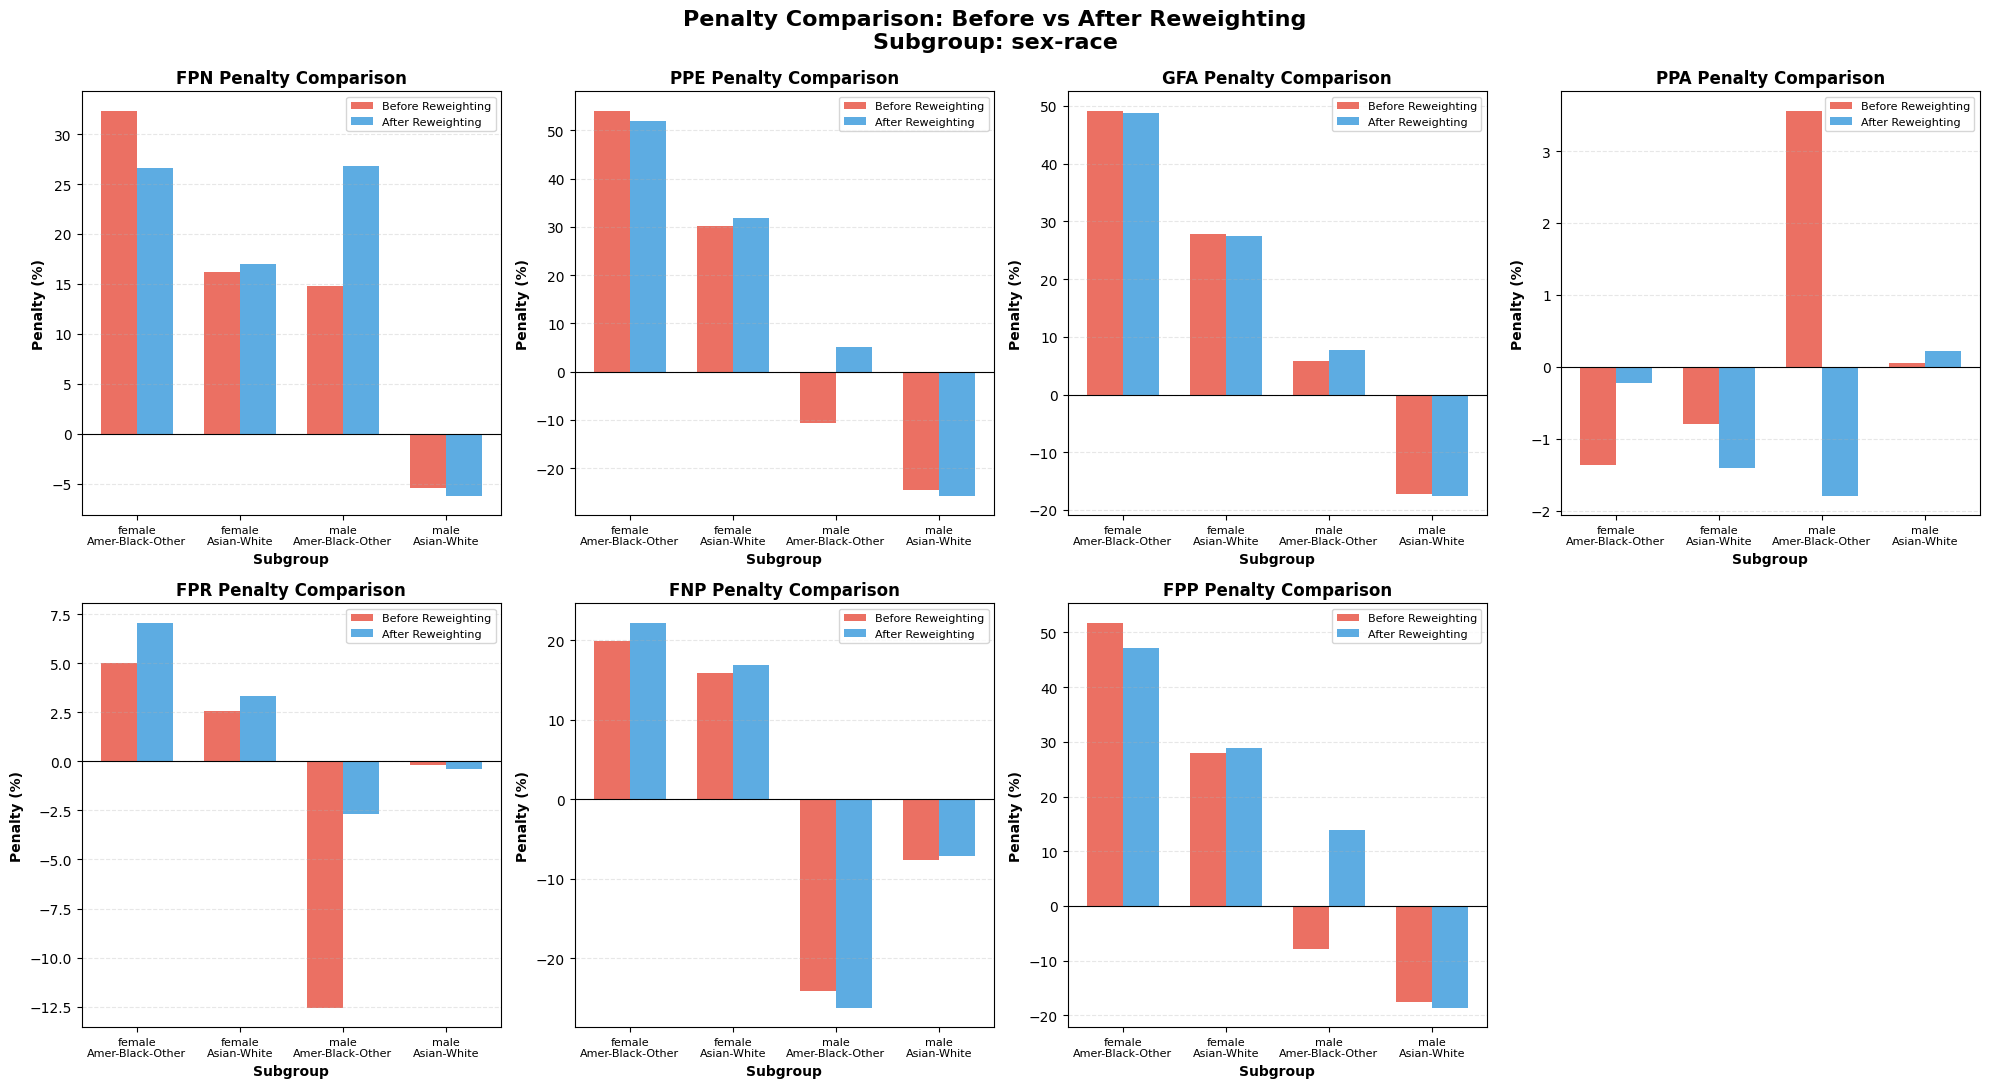

Training samples: 22792, Unique weights per group: {'00': 0.7554112554112554, '01': 1.2122527499630051, '10': 1.3599094567404426, '11': 0.9533244976222526}
{np.int64(0): array([[1406,   24],
       [  91,   89]]), np.int64(1): array([[2043,  206],
       [ 333,  693]])}
{np.int64(1): array([[2964,  221],
       [ 378,  752]]), np.int64(0): array([[485,   9],
       [ 46,  30]])}
{'01': array([[1144,   22],
       [  77,   80]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 301,  672]]), '10': array([[223,   7],
       [ 32,  21]])}
Training samples: 22792, Unique weights per group: {'00': 1.4230214230214229, '01': 1.3451328520210204, '10': 1.1935149146243582, '11': 0.7292196527673883}
{np.int64(0): array([[1406,   24],
       [  90,   90]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
{np.int64(1): array([[2964,  221],
       [ 374,  756]]), np.int64(0): array([[486,   8],
       [ 48,  28]])}
{'01': array([[1144,   22],
       [  75,  

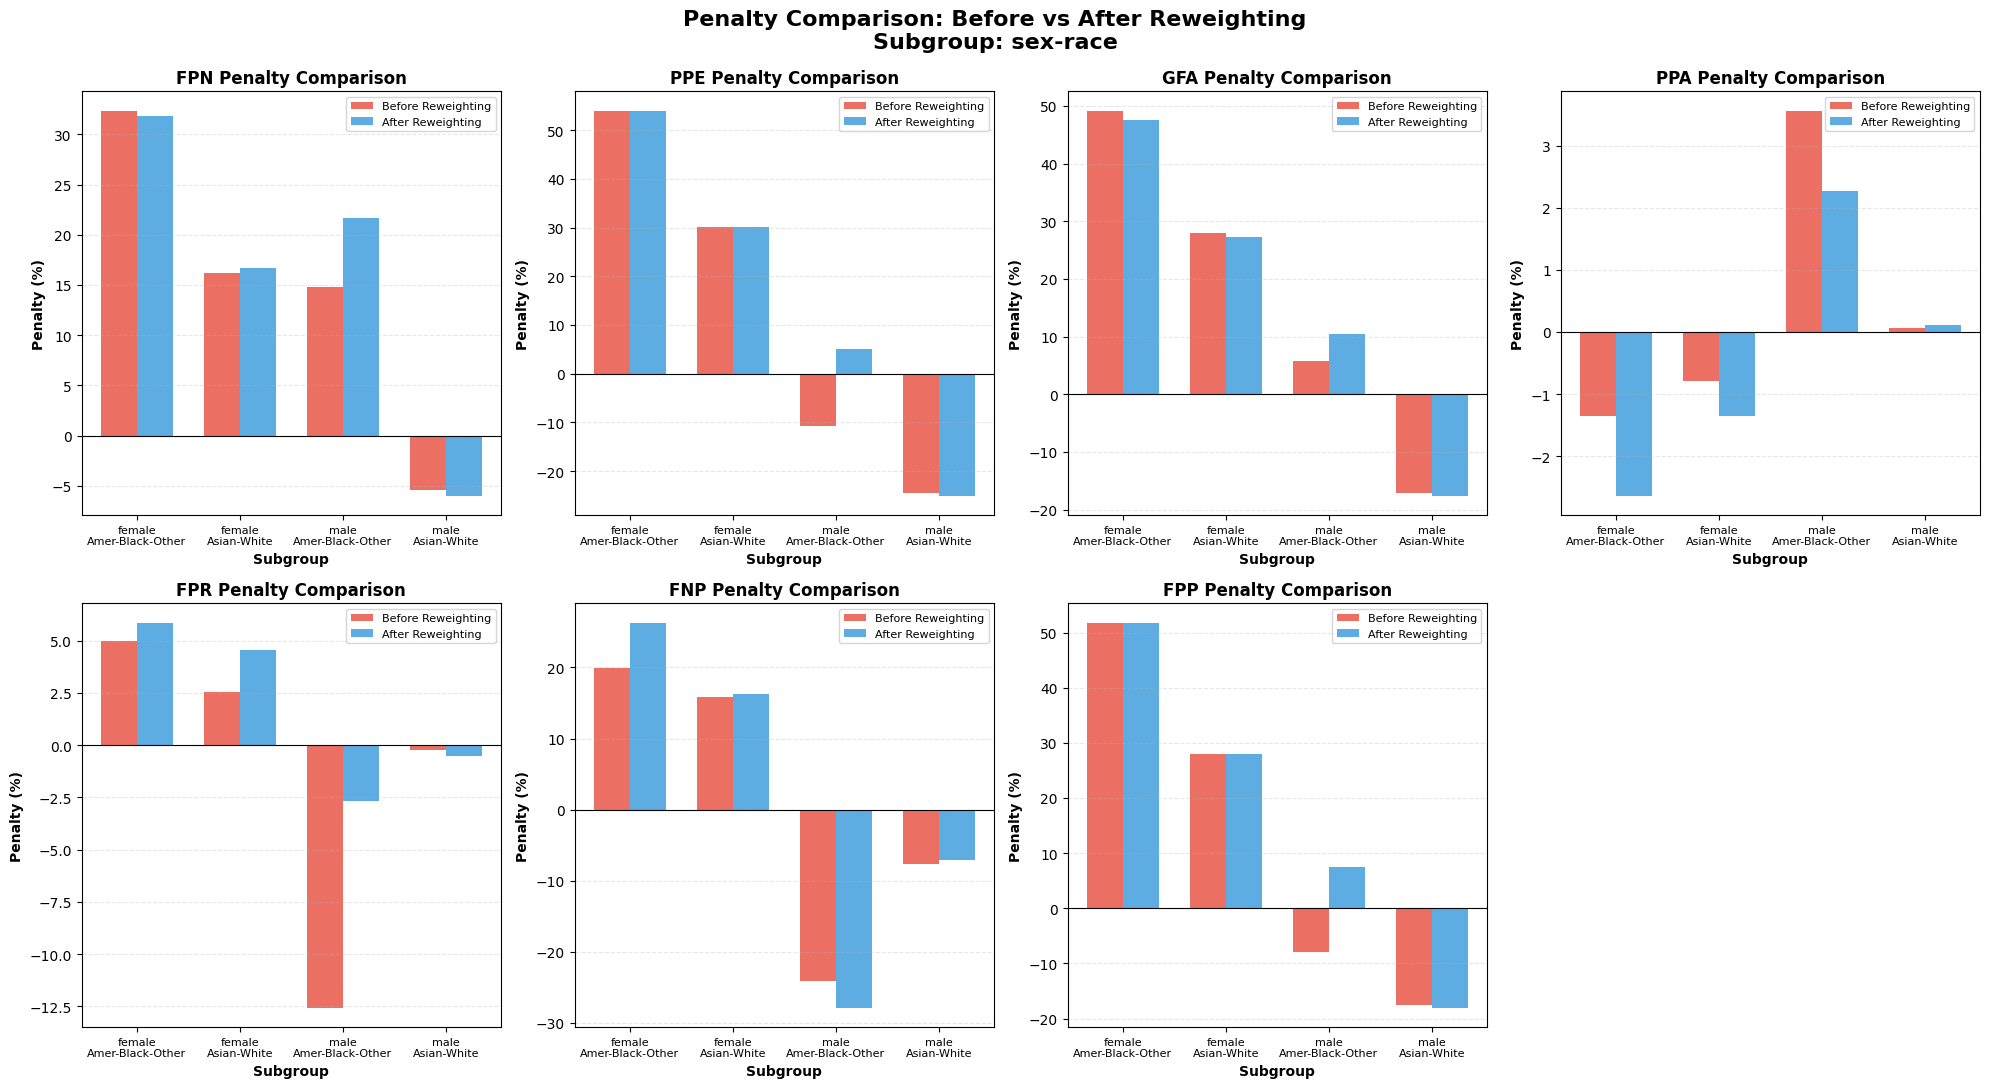

Training samples: 22792, Unique weights per group: {'00': 0.5108225108225108, '01': 1.4245054999260103, '10': 1.7198189134808852, '11': 0.906648995244505}
{np.int64(0): array([[1406,   24],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
{np.int64(1): array([[2964,  221],
       [ 373,  757]]), np.int64(0): array([[486,   8],
       [ 47,  29]])}
{'01': array([[1144,   22],
       [  73,   84]]), '00': array([[262,   2],
       [ 15,   8]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[224,   6],
       [ 32,  21]])}
Training samples: 22792, Unique weights per group: {'00': 1.8460428460428457, '01': 1.6902657040420408, '10': 1.3870298292487164, '11': 0.45843930553477663}
{np.int64(0): array([[1406,   24],
       [  90,   90]]), np.int64(1): array([[2044,  205],
       [ 333,  693]])}
{np.int64(1): array([[2964,  221],
       [ 375,  755]]), np.int64(0): array([[486,   8],
       [ 48,  28]])}
{'01': array([[1144,   22],
       [  75,  

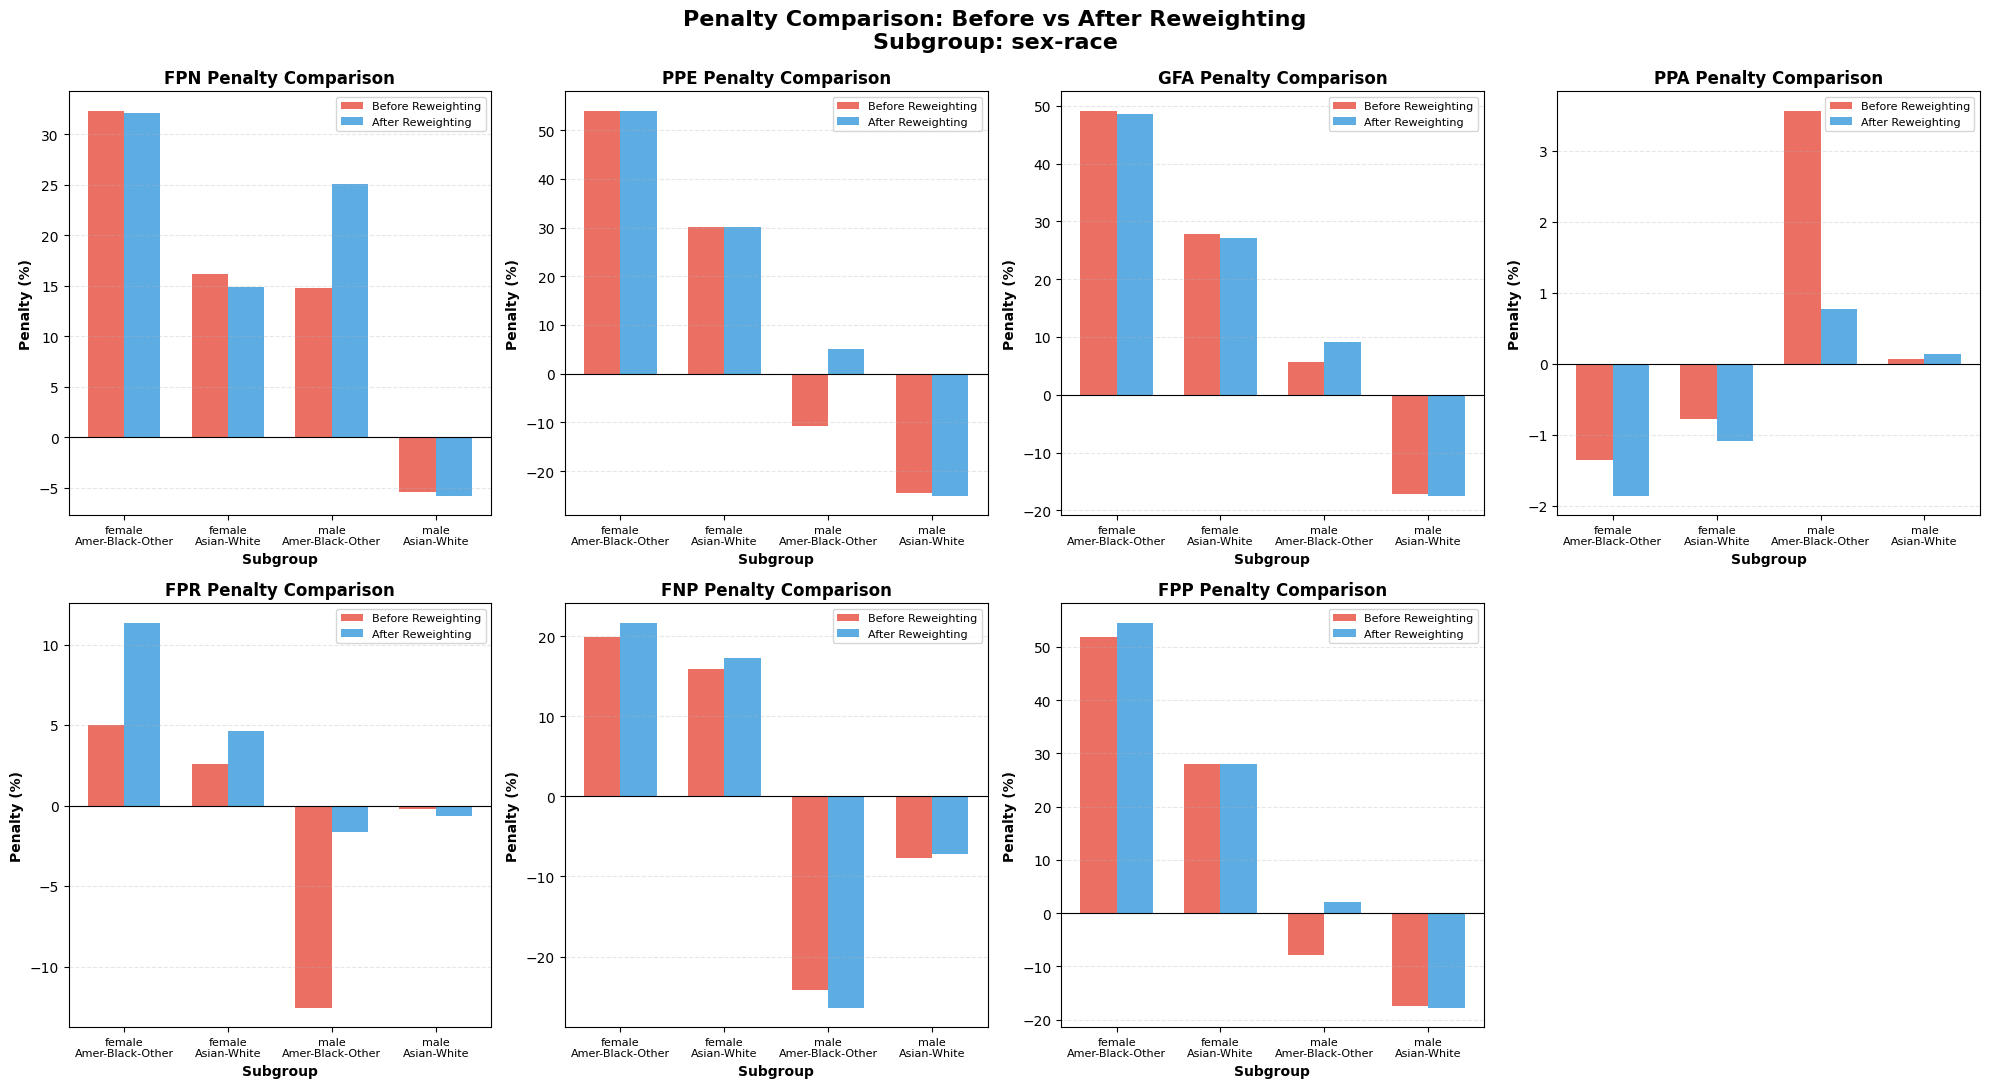

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
{np.int64(0): array([[1405,   25],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
{np.int64(1): array([[2964,  221],
       [ 374,  756]]), np.int64(0): array([[485,   9],
       [ 46,  30]])}
{'01': array([[1144,   22],
       [  74,   83]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[224,   6],
       [ 32,  21]])}
Training samples: 22792, Unique weights per group: {'00': 3.1151071151071146, '01': 2.725664260105102, '10': 1.967574573121791, '11': 0.01}
{np.int64(0): array([[1407,   23],
       [  90,   90]]), np.int64(1): array([[2009,  240],
       [ 350,  676]])}
{np.int64(1): array([[2931,  254],
       [ 391,  739]]), np.int64(0): array([[485,   9],
       [ 49,  27]])}
{'01': array([[1145,   21],
       [  75,   82]]), '00': array([[262,   2

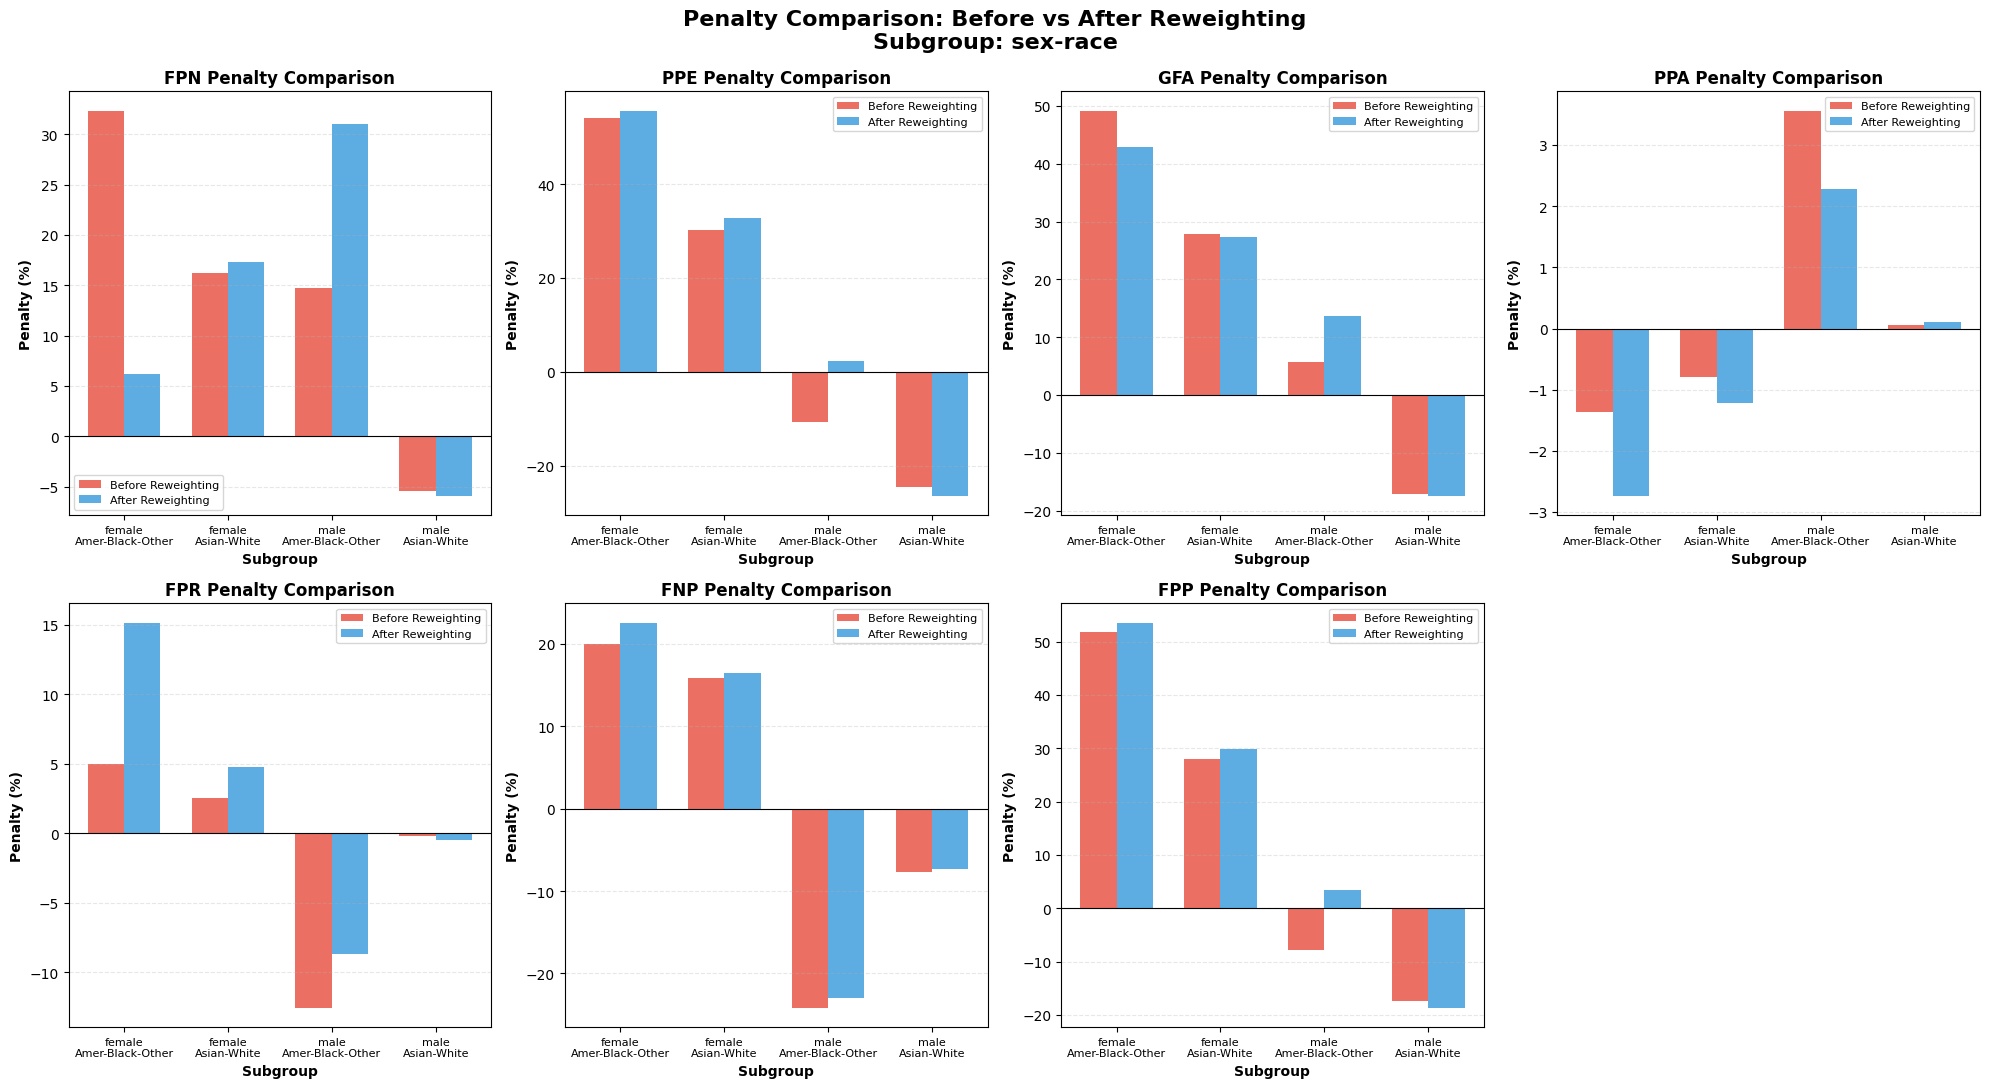

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 3.122527499630051, '10': 4.599094567404427, '11': 0.5332449762225253}
{np.int64(0): array([[1404,   26],
       [  91,   89]]), np.int64(1): array([[2045,  204],
       [ 335,  691]])}
{np.int64(1): array([[2964,  221],
       [ 378,  752]]), np.int64(0): array([[485,   9],
       [ 48,  28]])}
{'01': array([[1143,   23],
       [  77,   80]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1821,  198],
       [ 301,  672]]), '10': array([[224,   6],
       [ 34,  19]])}
Training samples: 22792, Unique weights per group: {'00': 5.230214230214229, '01': 4.451328520210204, '10': 2.935149146243582, '11': 0.01}
{np.int64(0): array([[1406,   24],
       [  90,   90]]), np.int64(1): array([[2015,  234],
       [ 343,  683]])}
{np.int64(1): array([[2942,  243],
       [ 397,  733]]), np.int64(0): array([[479,  15],
       [ 36,  40]])}
{'01': array([[1144,   22],
       [  75,   82]]), '00': array([[262,   2],


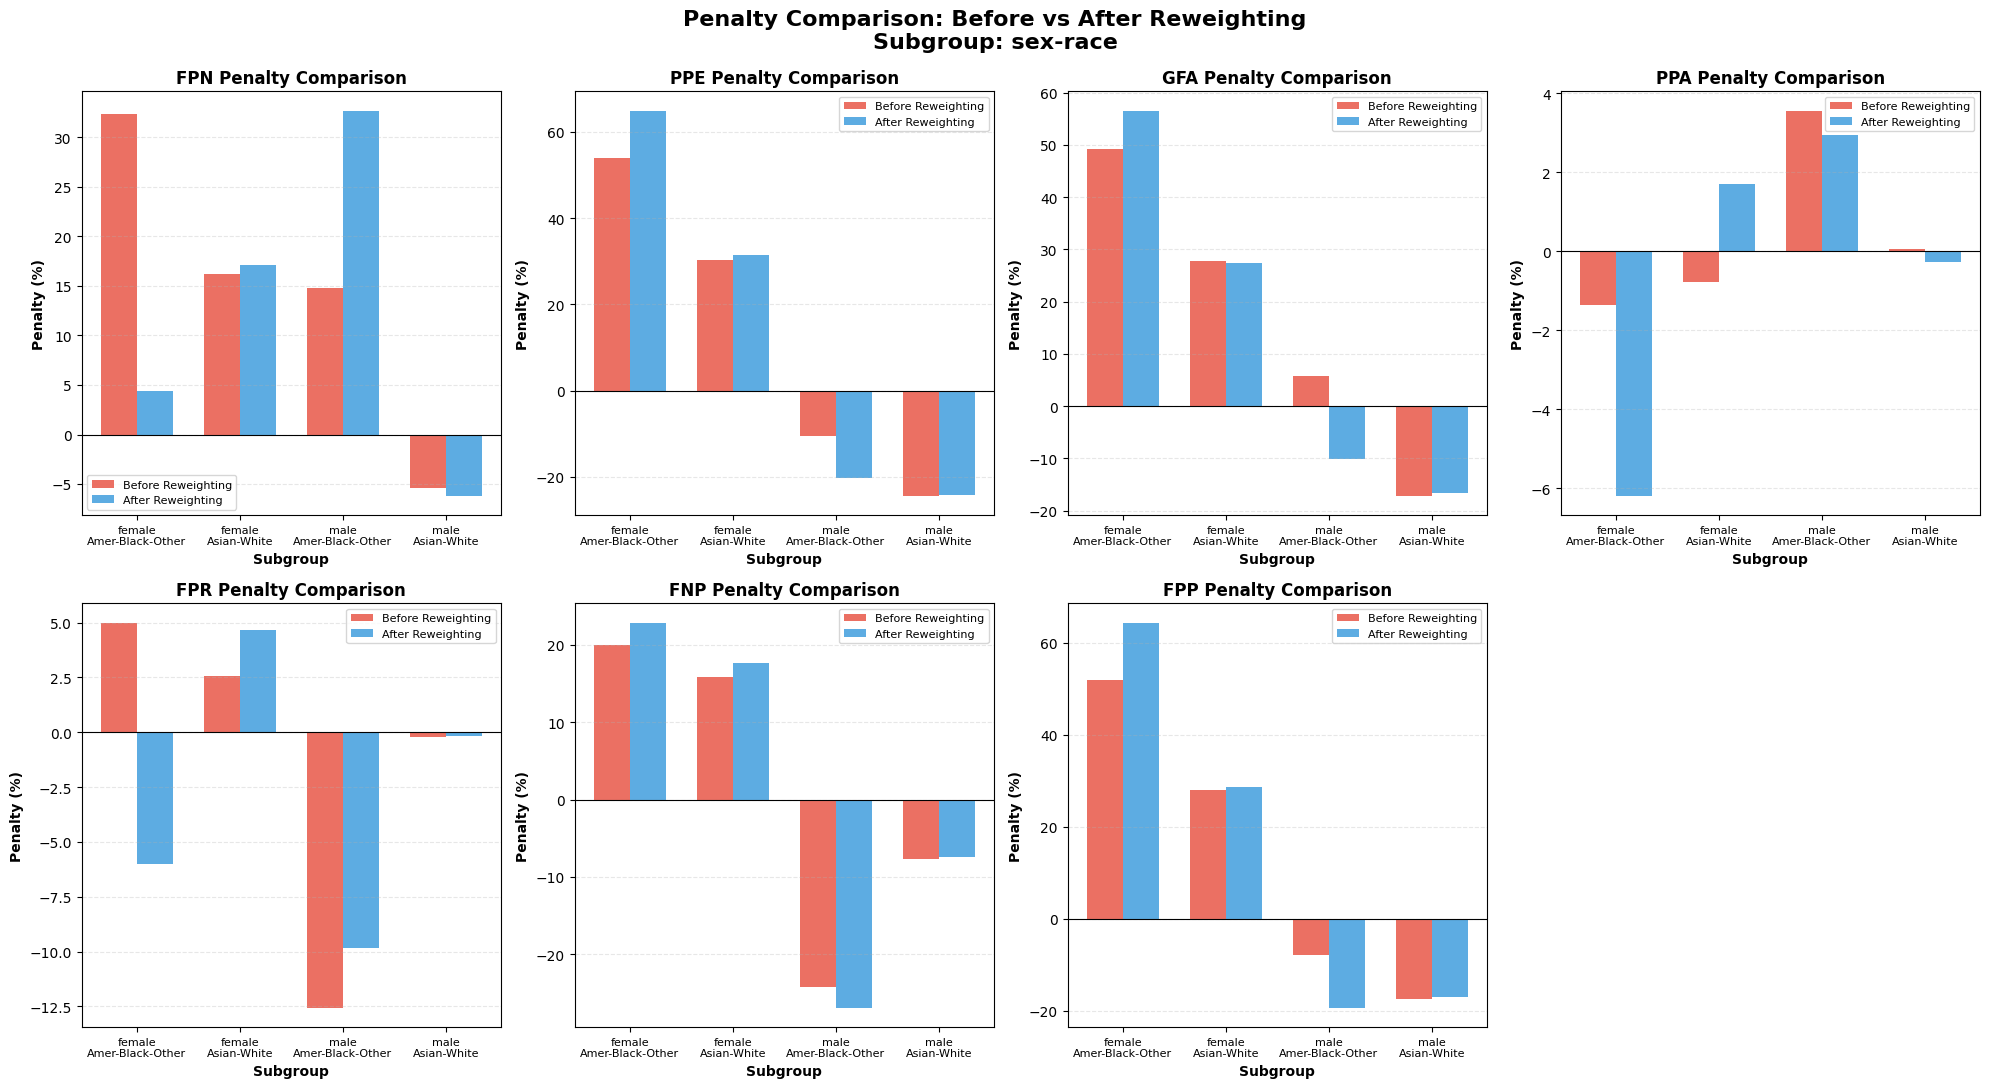

In [27]:
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

for l in lambdas:
    penalties_ontest_after_reweighting = {}

    fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
    for metric in fair_metrics:
        # print("FAIRNESS METRIC:", metric)
        weights_notsized = compute_weights_notsized(l, metric)
        penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
        # print("\n")

    fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
    plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                            sensible_attribute, mapping)

In [28]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        # Decode subgroup labels using mapping
        decoded_labels = []
        for group in subgroups:
            sex_code = group[0]
            race_code = group[1]
            sex_label = mapping['sex'][int(sex_code)]
            race_label = mapping['race'][int(race_code)]
            decoded_labels.append(f"{sex_label}\n{race_label}")
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)



Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
{np.int64(0): array([[1405,   25],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
{np.int64(1): array([[2964,  221],
       [ 374,  756]]), np.int64(0): array([[485,   9],
       [ 46,  30]])}
{'01': array([[1144,   22],
       [  74,   83]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[224,   6],
       [ 32,  21]])}


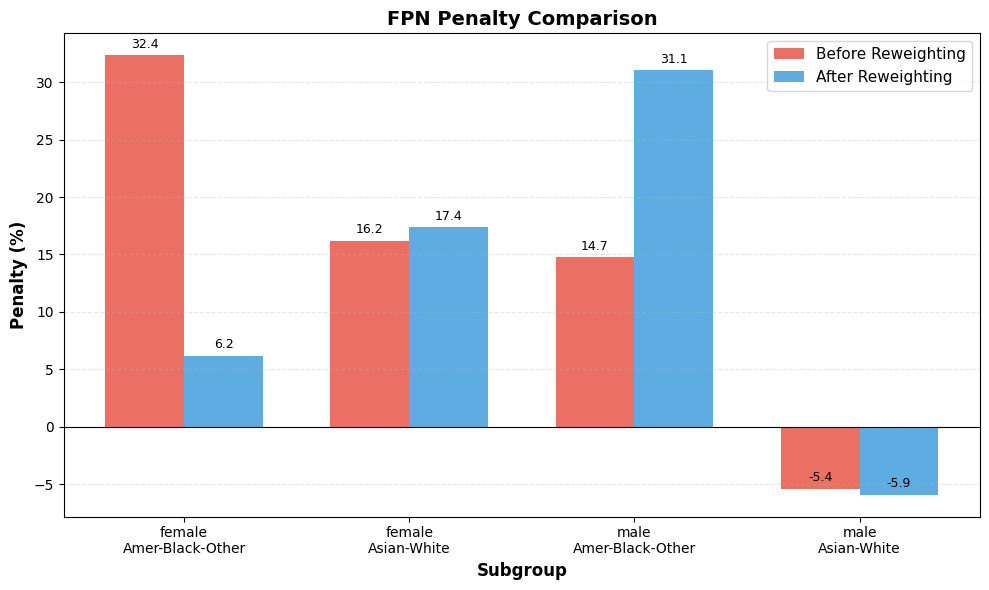


FPN - Penalty Changes:
  female-Amer-Black-Other: 32.35 → 6.20 (Δ = -26.16)
  female-Asian-White: 16.21 → 17.36 (Δ = +1.15)
  male-Amer-Black-Other: 14.75 → 31.07 (Δ = +16.32)
  male-Asian-White: -5.39 → -5.92 (Δ = -0.53)
------------------------------------------------------------


In [29]:
penalties_ontest_after_reweighting = {}
weights_notsized = compute_weights_notsized(5.0, 'FPN')
penalties_ontest_after_reweighting['FPN']= compute_penalties_after_reweighting(weights_notsized, 'FPN') # Get only harmonic penalty
plot_penalty_comparison_all_individual(['FPN'], penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping)

---